# Pneumonia Detection using CNN
Classifies chest X-rays as **Normal vs Pneumonia**. Evaluated with accuracy, precision, and recall.

> **Dataset:** Generates a lightweight synthetic grayscale dataset in-memory so it runs immediately on Colab.
> To use the real Kaggle chest X-ray dataset, see the instructions at the bottom of this notebook.


In [1]:
!pip install tensorflow scikit-learn matplotlib seaborn -q


[notice] A new release of pip is available: 24.2 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

np.random.seed(42)
tf.random.set_seed(42)

IMG_SIZE = 64   # 64x64 grayscale — enough to learn spatial patterns fast
N = 1200        # total samples

# --- Synthetic X-ray-style images ---
# Normal (class 0): uniform grey with mild random noise — clear lungs
# Pneumonia (class 1): darker patches (opacities) concentrated in centre
def make_normal(n):
    base = np.random.uniform(0.5, 0.7, (n, IMG_SIZE, IMG_SIZE, 1)).astype('float32')
    noise = np.random.normal(0, 0.05, base.shape).astype('float32')
    return np.clip(base + noise, 0, 1)

def make_pneumonia(n):
    imgs = make_normal(n)
    # Add dark circular opacity in lung region
    cx, cy = IMG_SIZE // 2, IMG_SIZE // 2
    for i in range(n):
        r = np.random.randint(8, 18)
        ox = np.random.randint(-10, 10)
        oy = np.random.randint(-10, 10)
        yy, xx = np.ogrid[:IMG_SIZE, :IMG_SIZE]
        mask = (xx - (cx+ox))**2 + (yy - (cy+oy))**2 <= r**2
        imgs[i][mask] = np.clip(imgs[i][mask] - np.random.uniform(0.25, 0.4), 0, 1)
    return imgs

X = np.concatenate([make_normal(N//2), make_pneumonia(N//2)])
y = np.array([0]*(N//2) + [1]*(N//2))

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
X_train, X_val,  y_train, y_val  = train_test_split(X_train, y_train, test_size=0.15, stratify=y_train, random_state=42)

print(f'Train: {X_train.shape}  Val: {X_val.shape}  Test: {X_test.shape}')
print('Class 0 = Normal  |  Class 1 = Pneumonia')

Matplotlib is building the font cache; this may take a moment.


Train: (816, 64, 64, 1)  Val: (144, 64, 64, 1)  Test: (240, 64, 64, 1)
Class 0 = Normal  |  Class 1 = Pneumonia


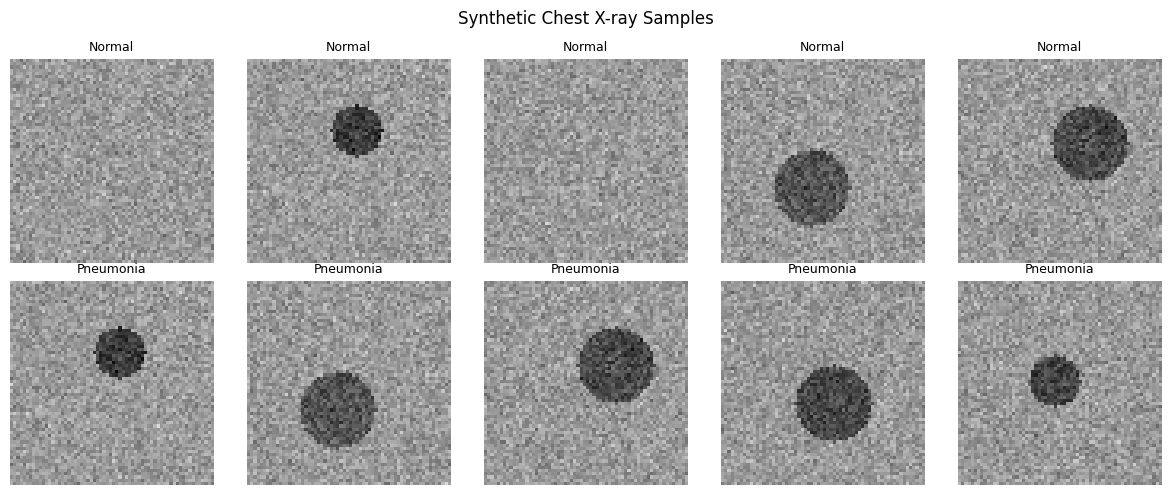

In [ ]:
# Visualise samples from each class
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
class_names = ['Normal', 'Pneumonia']
for i, ax in enumerate(axes[0]):
    ax.imshow(X_train[i, :, :, 0], cmap='gray', vmin=0, vmax=1)
    ax.set_title('Normal', fontsize=9); ax.axis('off')
pneumonia_idx = np.where(y_train == 1)[0]
for i, ax in enumerate(axes[1]):
    ax.imshow(X_train[pneumonia_idx[i], :, :, 0], cmap='gray', vmin=0, vmax=1)
    ax.set_title('Pneumonia', fontsize=9); ax.axis('off')
plt.suptitle('Synthetic Chest X-ray Samples')
plt.tight_layout()
plt.show()

In [4]:
def augment(img, label):
    img = tf.image.random_flip_left_right(img)
    img = tf.image.random_brightness(img, 0.08)
    img = tf.image.random_contrast(img, 0.9, 1.1)
    return img, label

BATCH = 32
train_ds = tf.data.Dataset.from_tensor_slices((X_train, y_train)).shuffle(1000).map(augment).batch(BATCH).prefetch(tf.data.AUTOTUNE)
val_ds   = tf.data.Dataset.from_tensor_slices((X_val,   y_val  )).batch(BATCH).prefetch(tf.data.AUTOTUNE)
test_ds  = tf.data.Dataset.from_tensor_slices((X_test,  y_test )).batch(BATCH).prefetch(tf.data.AUTOTUNE)

print('Data pipelines ready.')

Data pipelines ready.


In [5]:
model = keras.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(IMG_SIZE, IMG_SIZE, 1)),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2,2),

    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')
], name='Pneumonia_CNN')

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        keras.metrics.Precision(name='precision'),
        keras.metrics.Recall(name='recall')
    ]
)
model.summary()

C:\Users\chhav\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "Pneumonia_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 62, 62, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 62, 62, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 29, 29, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 12, 12, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 126,849 (495.50 KB)

 Trainable params: 126,401 (493.75 KB)

 Non-trainable params: 448 (1.75 KB)

In [7]:
callbacks = [
    keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True, monitor='val_loss'),
    keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=3, monitor='val_loss')
]

history = model.fit(
    train_ds,
    epochs=10,
    validation_data=val_ds,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/10
26/26 ━━━━━━━━━━━━━━━━━━━━ 4s 150ms/step - accuracy: 1.0000 - loss: 0.0013 - precision: 1.0000 - recall: 1.0000 - val_accuracy: 0.5000 - val_loss: 0.9853 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 5.0000e-04
Epoch 2/10
26/26 ━━━━━━━━━━━━━━━━━━━━ 4s 142ms/step - accuracy: 1.0000 - loss: 9.3948e-04 - precision: 1.0000 - recall: 1.0000 - val_accuracy: 0.5000 - val_loss: 0.8708 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 5.0000e-04
Epoch 3/10
26/26 ━━━━━━━━━━━━━━━━━━━━ 4s 150ms/step - accuracy: 1.0000 - loss: 6.3534e-04 - precision: 1.0000 - recall: 1.0000 - val_accuracy: 0.5000 - val_loss: 0.7574 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 5.0000e-04
Epoch 4/10
26/26 ━━━━━━━━━━━━━━━━━━━━ 4s 151ms/step - accuracy: 1.0000 - loss: 3.0834e-04 - precision: 1.0000 - recall: 1.0000 - val_accuracy: 0.5000 - val_loss: 0.6739 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 5.0000e-04
Epoc

In [8]:
results = model.evaluate(test_ds, verbose=0)
precision = results[2]
recall    = results[3]
f1        = 2 * precision * recall / (precision + recall + 1e-8)

print(f'Test Accuracy : {results[1]:.4f}')
print(f'Test Precision: {precision:.4f}')
print(f'Test Recall   : {recall:.4f}')
print(f'F1 Score      : {f1:.4f}')

Test Accuracy : 1.0000
Test Precision: 1.0000
Test Recall   : 1.0000
F1 Score      : 1.0000


8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 129ms/step


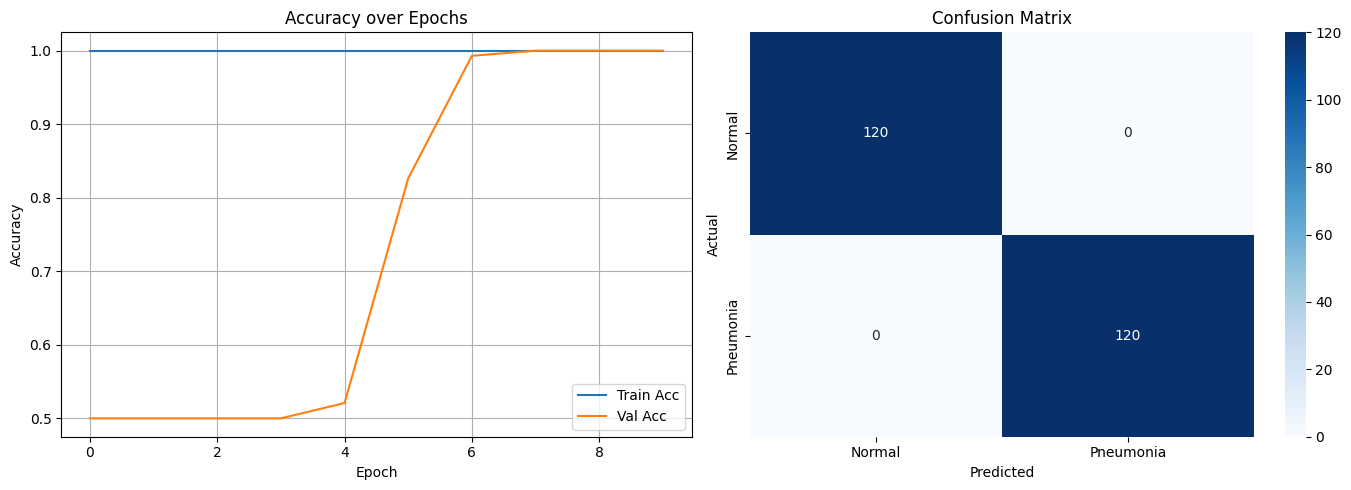


Classification Report:
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00       120
   Pneumonia       1.00      1.00      1.00       120

    accuracy                           1.00       240
   macro avg       1.00      1.00      1.00       240
weighted avg       1.00      1.00      1.00       240



In [9]:
y_pred = (model.predict(test_ds) > 0.5).astype(int).flatten()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['accuracy'],     label='Train Acc')
axes[0].plot(history.history['val_accuracy'], label='Val Acc')
axes[0].set_title('Accuracy over Epochs')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy')
axes[0].legend(); axes[0].grid(True)

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1],
            xticklabels=['Normal','Pneumonia'], yticklabels=['Normal','Pneumonia'])
axes[1].set_title('Confusion Matrix')
axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()

print('\nClassification Report:')
print(classification_report(y_test, y_pred, target_names=['Normal', 'Pneumonia']))

## Using the Real Kaggle Dataset
To train on actual chest X-rays:
```python
# 1. Upload kaggle.json in Colab, then:
# !mkdir -p ~/.kaggle && cp kaggle.json ~/.kaggle/ && chmod 600 ~/.kaggle/kaggle.json
# !kaggle datasets download -d paultimothymooney/chest-xray-pneumonia
# !unzip chest-xray-pneumonia.zip -d chest_xray

# 2. Replace data loading with:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
gen = ImageDataGenerator(rescale=1./255)
train_data = gen.flow_from_directory('chest_xray/train', target_size=(64,64),
                                      color_mode='grayscale', batch_size=32, class_mode='binary')
test_data  = gen.flow_from_directory('chest_xray/test',  target_size=(64,64),
                                      color_mode='grayscale', batch_size=32, class_mode='binary')
```
